In [73]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet18
from sklearn.linear_model import Lasso
import cv2 as cv


def load_image(path):
    img = Image.open(path).convert("RGB")
    return img.resize((224, 224))


def kmeans_numpy(X, n_clusters, max_iter=100, tol=1e-4):
    n = X.shape[0]
    # Randomly choose initial centroids from the data
    idx = np.random.choice(n, size=n_clusters, replace=False)
    centroids = X[idx].copy()
    labels = np.zeros(n, dtype=np.int32)
    for it in range(max_iter):
        # Assign each point to nearest centroid
        dists = np.linalg.norm(X[:, None] - centroids[None], axis=2)  # (n, k)
        new_labels = np.argmin(dists, axis=1)
        # Update centroids
        new_centroids = np.array(
            [X[new_labels == j].mean(axis=0) for j in range(n_clusters)]
        )
        # If a cluster is empty, re‑initialize its centroid randomly
        for j in range(n_clusters):
            if not np.any(new_labels == j):
                new_centroids[j] = X[np.random.choice(n)]
        # Check convergence
        if np.allclose(centroids, new_centroids, atol=tol):
            labels = new_labels
            centroids = new_centroids
            break
        centroids = new_centroids
        labels = new_labels
    return centroids, labels


def kmeans_segments(image_uint8, n_segments=64, max_iter=50):
    H, W = image_uint8.shape[:2]
    xs, ys = np.meshgrid(np.arange(W), np.arange(H))
    features = np.column_stack(
        [
            image_uint8.reshape(-1, 3).astype(float),
            ys.ravel().astype(float) * (255.0 / H),
            xs.ravel().astype(float) * (255.0 / W),
        ]
    )
    centroids, labels = kmeans_numpy(features, n_segments, max_iter=max_iter)
    return labels.reshape(H, W)

In [74]:
# MODEL_PATH = "resnet18-f37072fd.pth"
MODEL_PATH = r"./TAI_HW2_Files/Model Weights (Q1 & Q2)/resnet18-f37072fd.pth"
np.random.seed(42)
torch.manual_seed(42)

# Set device
device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
print("Using device:", device)

# Load model architecture and weights
model = resnet18(weights=None)
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()
print("Model loaded from", MODEL_PATH)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

Using device: mps
Model loaded from ./TAI_HW2_Files/Model Weights (Q1 & Q2)/resnet18-f37072fd.pth


Predicted class index: 282
Prob 13.686553


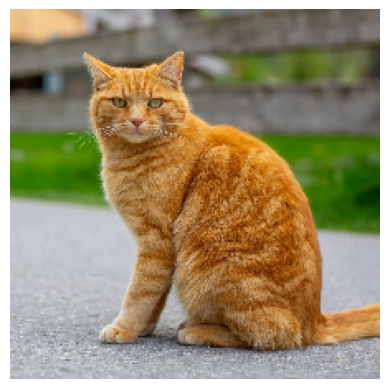

In [75]:
image_path = r"./TAI_HW2_Files/Q1/code/cat.jpg"
img = cv.imread(image_path, cv.IMREAD_COLOR)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img = cv.resize(img, (224, 224))

plt.imshow(img)
plt.axis("off")
pred = model(transform(img).unsqueeze(0).to(device)).cpu().detach().numpy()
plt.savefig('./report/images/q1_cat.png')
print("Predicted class index:", np.argmax(pred))
print("Prob", pred[0, 282])

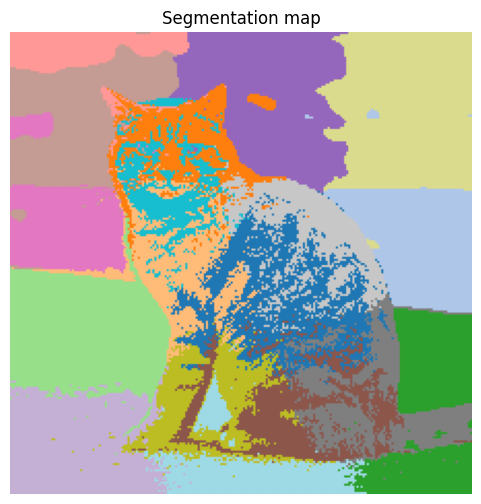

In [76]:
segs = kmeans_segments(img, n_segments=18)
plt.figure(figsize=(6, 6))
plt.imshow(segs, cmap="tab20")
plt.axis("off")
plt.title("Segmentation map")
plt.savefig('./report/images/q1_segcat.png')
plt.show()

In [77]:
masks = np.random.randint(0, 2, size=(1000, 18), dtype=np.uint8)
masks.shape, masks.min(), masks.max()

((1000, 18), np.uint8(0), np.uint8(1))

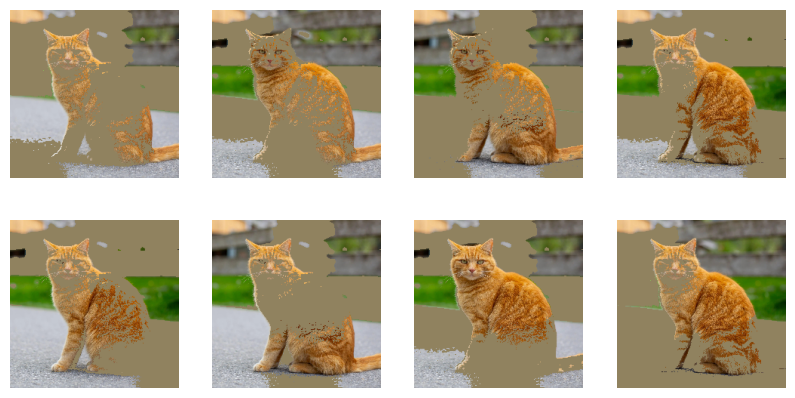

In [78]:
def mask_img(img, mask, segments):
    if (
        len(mask) != np.max(segments) + 1
        and len(mask) != segments.max() + 1
    ):
        raise ValueError("binary_array must have one entry per segment")

    output = img.copy().astype(np.float32)
    average_color = img.mean(axis=(0, 1))

    for segment_index, keep in enumerate(mask):
        if keep == 0:
            output[segments == segment_index] = average_color

    return output.astype(np.uint8)


plt.figure(figsize=(10, 5))
for i in range(4):
    for j in range(2):
        masked_img = mask_img(img, masks[i * 2 + j], segs)
        plt.subplot(2, 4, i * 2 + j + 1)
        plt.imshow(masked_img)
        plt.axis("off")
plt.savefig('./report/images/q1_maskcat.png')
plt.show()

In [79]:
def get_weights(masks, eps=1e-8):
    masks = np.asarray(masks, dtype=np.float32)
    d = masks.shape[1]
    sigma = 0.25 * np.sqrt(d)
    original = np.ones(d, dtype=np.float32)
    original_norm = np.linalg.norm(original)
    code_norms = np.linalg.norm(masks, axis=1)
    dist = 1.0 - (masks @ original) / (code_norms * original_norm + eps)
    weights = np.exp(-(dist**2) / (sigma**2))
    return weights, dist, sigma


weights, distances, sigma = get_weights(masks)
print("sigma =", sigma)


sigma = 1.0606601717798212


In [80]:

def predict(img, masks, segs, correct_class: int):
    masks = masks.astype(np.float32)
    n_samples = len(masks)
    modified_probs = np.empty(n_samples, dtype=np.float32)
    batch_size = 256

    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            end = min(start + batch_size, n_samples)
            batch_codes = masks[start:end]
            batch_images = np.stack(
                [mask_img(img, code, segs) for code in batch_codes]
            )
            batch_tensor = torch.stack([transform(mod_img) for mod_img in batch_images]).to(
                device
            )
            batch_probs = torch.softmax(model(batch_tensor), dim=1)[:, correct_class].cpu().numpy()
            modified_probs[start:end] = batch_probs
    return modified_probs

probs = predict(img, masks, segs, correct_class=282)
linear_model = Lasso(alpha=0.1, fit_intercept=False, max_iter=10000)
linear_model.fit(masks, probs)
coefficients = linear_model.coef_


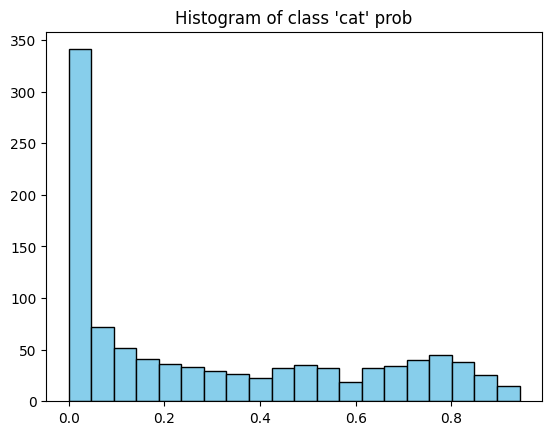

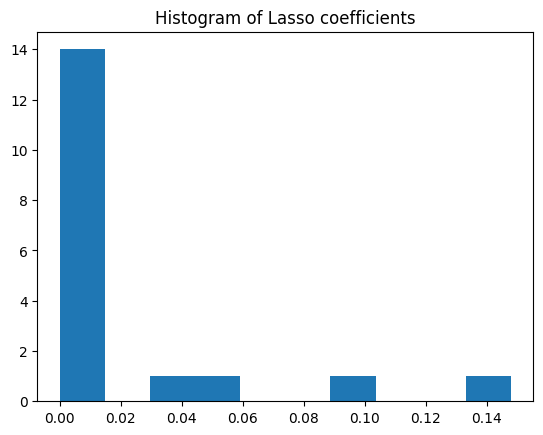

In [81]:
plt.title("Histogram of class 'cat' prob")
plt.hist(probs, bins=20, color="skyblue", edgecolor="black")
plt.savefig('./report/images/q1_histcat.png')
plt.show()

top_negative = np.argsort(coefficients)[:5]
plt.title("Histogram of Lasso coefficients")
plt.hist(coefficients)
plt.savefig('./report/images/q1_histlasso.png')
plt.show()

print()

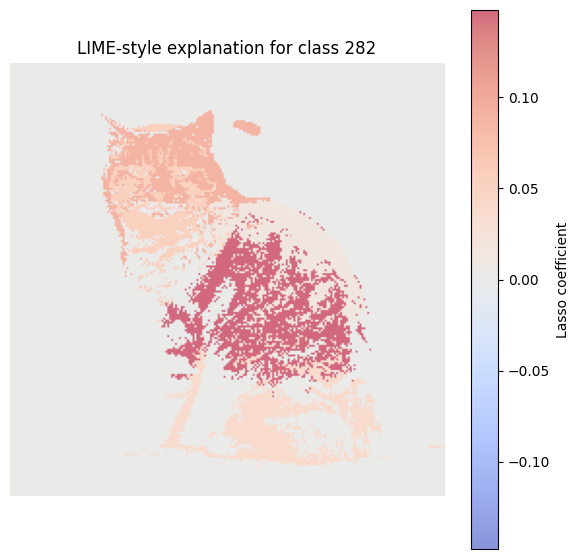

In [82]:
coef_map = coefficients[segs]
scale = np.max(np.abs(coefficients)) if np.max(np.abs(coefficients)) > 0 else 1.0
plt.figure(figsize=(7, 7))
plt.imshow(coef_map, cmap="coolwarm", alpha=0.6, vmin=-scale, vmax=scale)
plt.colorbar(label="Lasso coefficient")
plt.axis("off")
plt.title("LIME-style explanation for class 282")
plt.savefig('./report/images/q1_catcoefmap.png')
plt.show()

Predicted class index: 296


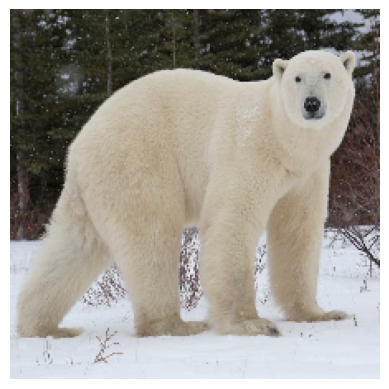

In [83]:

image_path = r"./TAI_HW2_Files/Q1/code/polarBear.png"
img = cv.imread(image_path, cv.IMREAD_COLOR)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img = cv.resize(img, (224, 224))

plt.imshow(img)
plt.axis("off")
pred = model(transform(img).unsqueeze(0).to(device)).cpu().detach().numpy()
print("Predicted class index:", np.argmax(pred))
plt.savefig('./report/images/q1_polarbear.png')
plt.show()

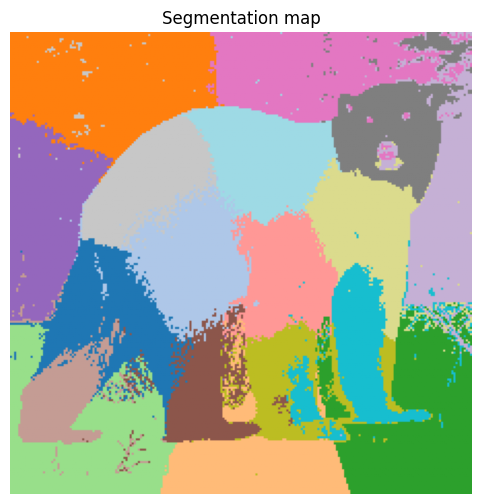

In [84]:
segs = kmeans_segments(img, n_segments=18)
plt.figure(figsize=(6, 6))
plt.imshow(segs, cmap="tab20")
plt.axis("off")
plt.title("Segmentation map")
plt.savefig('./report/images/q1_segpolarbear.png')
plt.show()

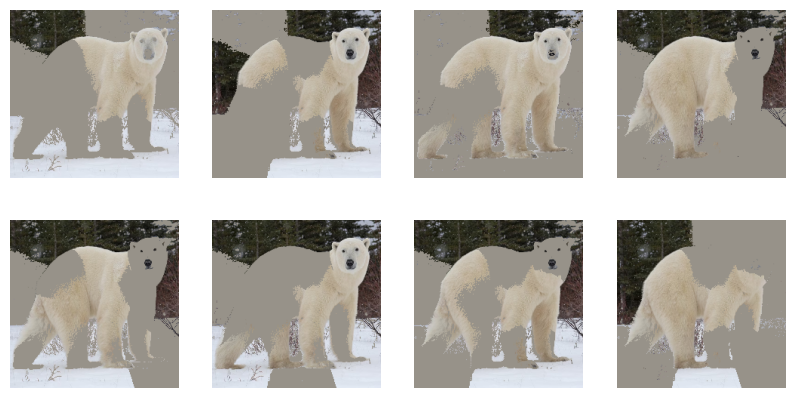

In [85]:
plt.figure(figsize=(10, 5))
for i in range(4):
    for j in range(2):
        masked_img = mask_img(img, masks[i * 2 + j], segs)
        plt.subplot(2, 4, i * 2 + j + 1)
        plt.imshow(masked_img)
        plt.axis("off")
plt.savefig('./report/images/q1_maskbear.png')
plt.show()

In [86]:
weights, distances, sigma = get_weights(masks)
print("sigma =", sigma)

sigma = 1.0606601717798212


In [87]:
probs = predict(img, masks, segs, correct_class=296)
linear_model = Lasso(alpha=0.1, fit_intercept=False, max_iter=10000)
linear_model.fit(masks, probs)
coefficients = linear_model.coef_

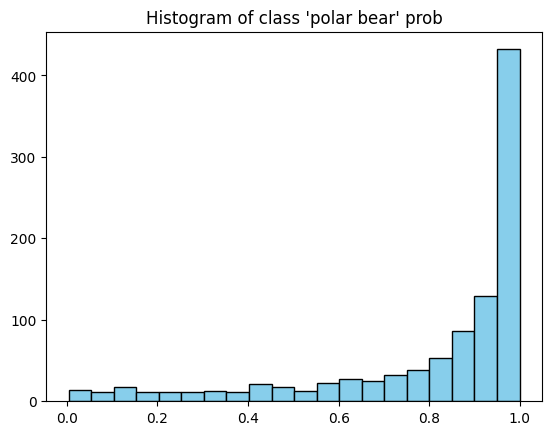

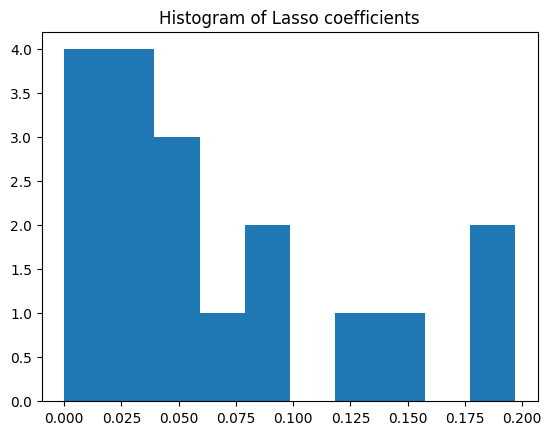

In [88]:
plt.title("Histogram of class 'polar bear' prob")
plt.hist(probs, bins=20, color="skyblue", edgecolor="black")
plt.savefig('./report/images/q1_histbear.png')
plt.show()

top_negative = np.argsort(coefficients)[:5]
plt.title("Histogram of Lasso coefficients")
plt.savefig('./report/images/q1_histlasso.png')
plt.hist(coefficients)
plt.show()

print()

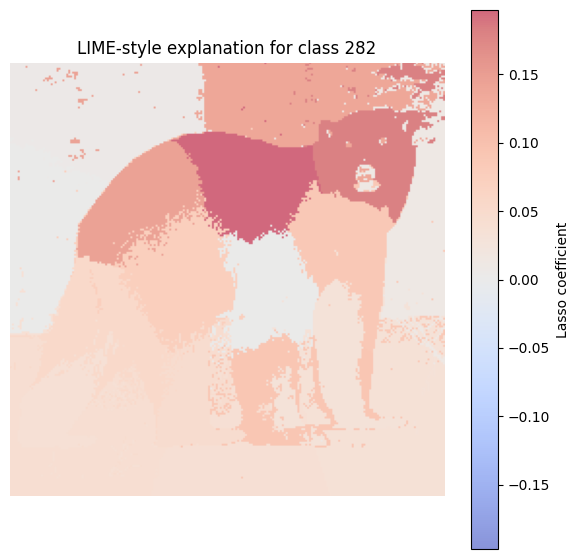

In [89]:
coef_map = coefficients[segs]
scale = np.max(np.abs(coefficients)) if np.max(np.abs(coefficients)) > 0 else 1.0
plt.figure(figsize=(7, 7))
plt.imshow(coef_map, cmap="coolwarm", alpha=0.6, vmin=-scale, vmax=scale)
plt.colorbar(label="Lasso coefficient")
plt.axis("off")
plt.title("LIME-style explanation for class 282")
plt.savefig('./report/images/q1_bearcoefmap.png')
plt.show()